In [48]:
!pip install sep
import numpy as np
import sep

In [49]:
import astropy.io.fits as astrofits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

Read image into np array

In [50]:
data = astrofits.open("hlsp.fits")
imageData = data[0].data


Show Image

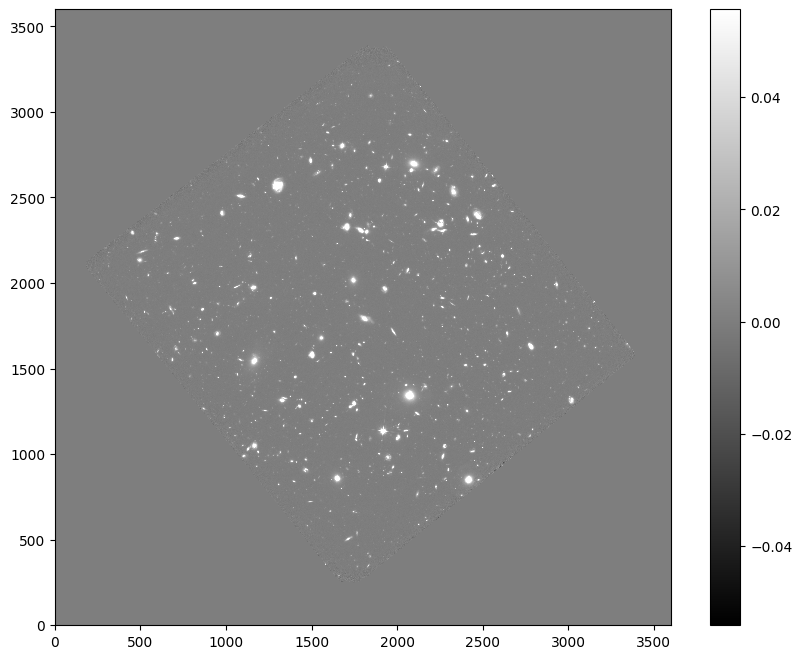

In [51]:
m, s = np.mean(imageData), np.std(imageData)  # Use image_data for calculations
plt.imshow(imageData, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();
plt.savefig("image.png")

Measure and Get Background Mean

In [52]:
imageData = imageData.byteswap(inplace=True).newbyteorder()
bkg = sep.Background(imageData)

# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


Background Image

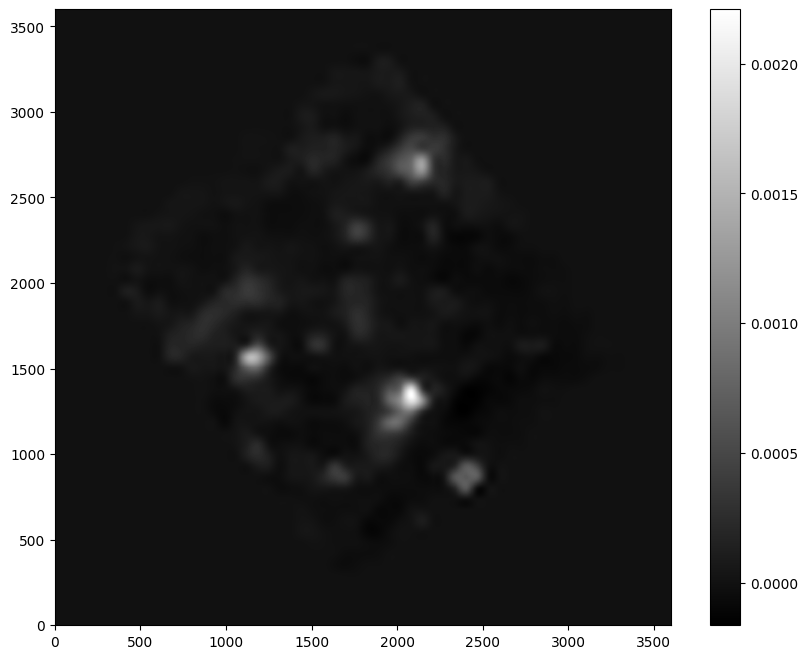

In [53]:
bkg_image = bkg.back()

plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("background.png")

Background Noise Image

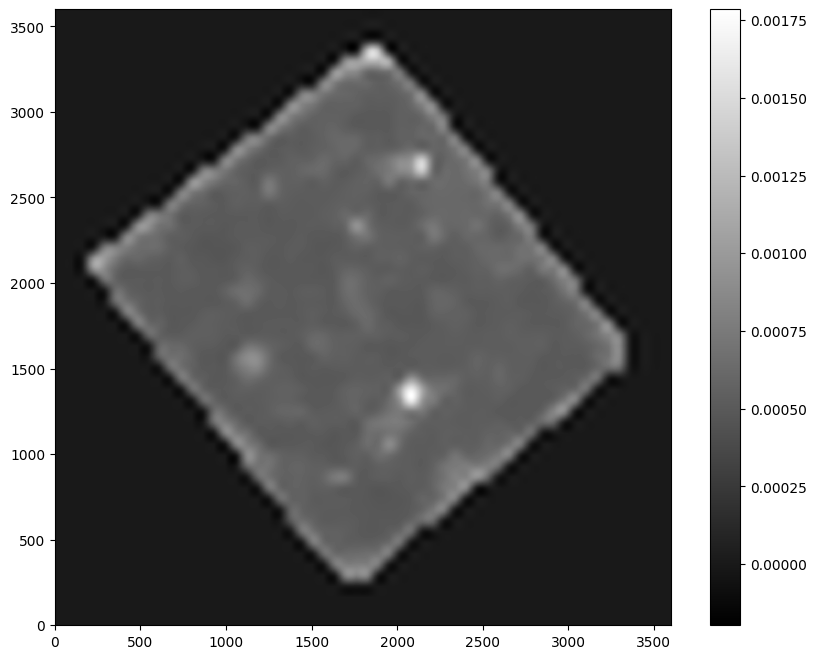

In [54]:
bkg_rms = bkg.rms()

plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("backgroundnoise.png")

Subtracting Background

In [55]:
data_sub = imageData - bkg

Objects Detected

In [56]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)
len(objects)

8643

Plotting Ellipses

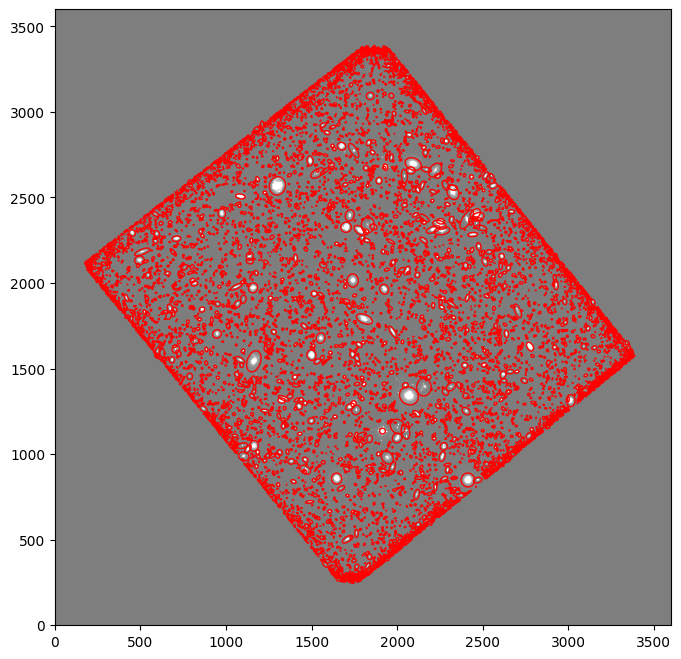

In [57]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig("ellipse1.png")

Available Fields

In [58]:
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

Show Object Results

In [59]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

print(f"The number of sources in the UDF image is {len(objects)}.")


object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877
The number of sources in the UDF image is 8643.


Flux Histogram

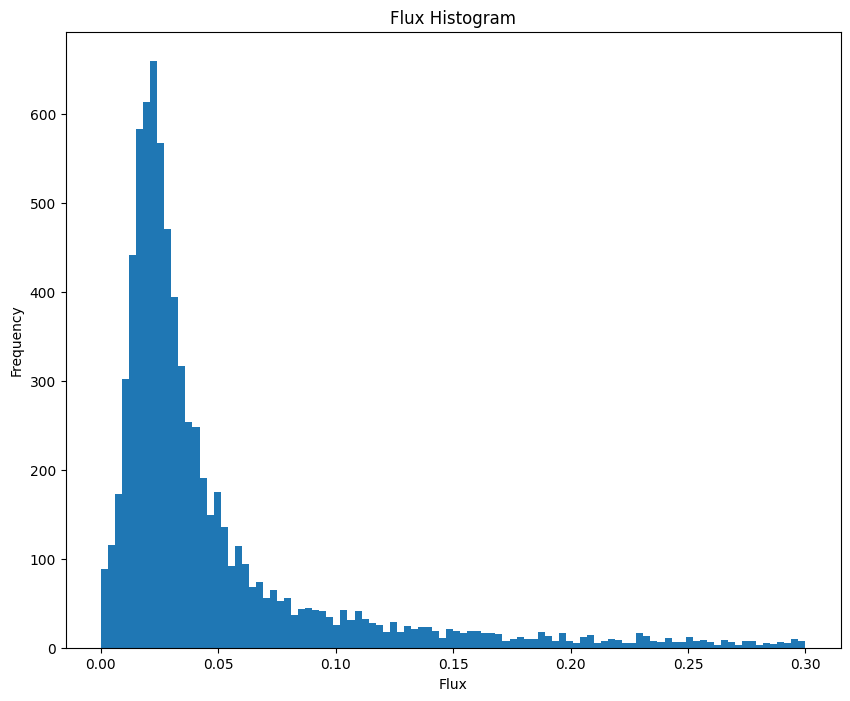

In [60]:
plt.hist(flux, bins=100, range=(0,0.3))
plt.xlabel("Flux")
plt.ylabel("Frequency")
plt.title("Flux Histogram")
plt.savefig("histogram.png")

Mean, Median, Deviation

In [61]:
print(f"The mean is {np.mean(flux)}")
print(f"The median is {np.median(flux)}")
print(f"The standard deviation is {np.std(flux)}")

The mean is 0.3617466258281149
The median is 0.030954822942148894
The standard deviation is 9.241925555851745


Outlier

In [62]:
upperVal = np.max(flux) - np.mean(flux)
lowerVal = np.mean(flux) - np.min(flux)

if upperVal > lowerVal:
    outlier = np.max(flux)
else:
    outlier = np.min(flux)

print(f"The outlier is {outlier}")

deviations = (outlier - np.mean(flux)) / np.std(flux)
print(f"The outlier is {deviations} deviations away from the mean")

The outlier is 807.2972835731507
The outlier is 87.31249046216263 deviations away from the mean


Ellipse Outlier Image

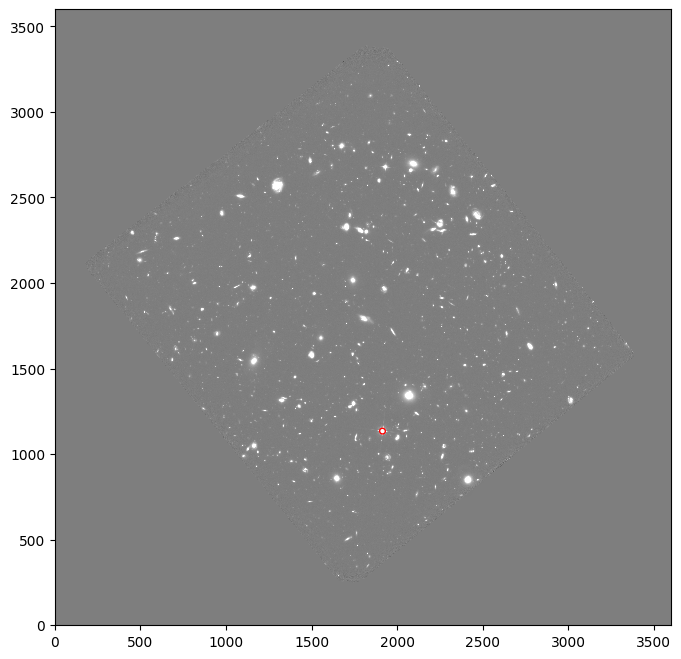

In [63]:
#create new image plot
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

#plot an ellipse at outlier index
deviationsIndex = np.where(flux == outlier)
e = Ellipse(xy=(objects['x'][deviationsIndex], objects['y'][deviationsIndex]),
                width=6*objects['a'][deviationsIndex],
                height=6*objects['b'][deviationsIndex],
                angle=objects['theta'][deviationsIndex] * 180. / np.pi)
e.set_facecolor('none')
e.set_edgecolor('red')
ax.add_artist(e)

plt.savefig("ellipse2.png")

False Color Image

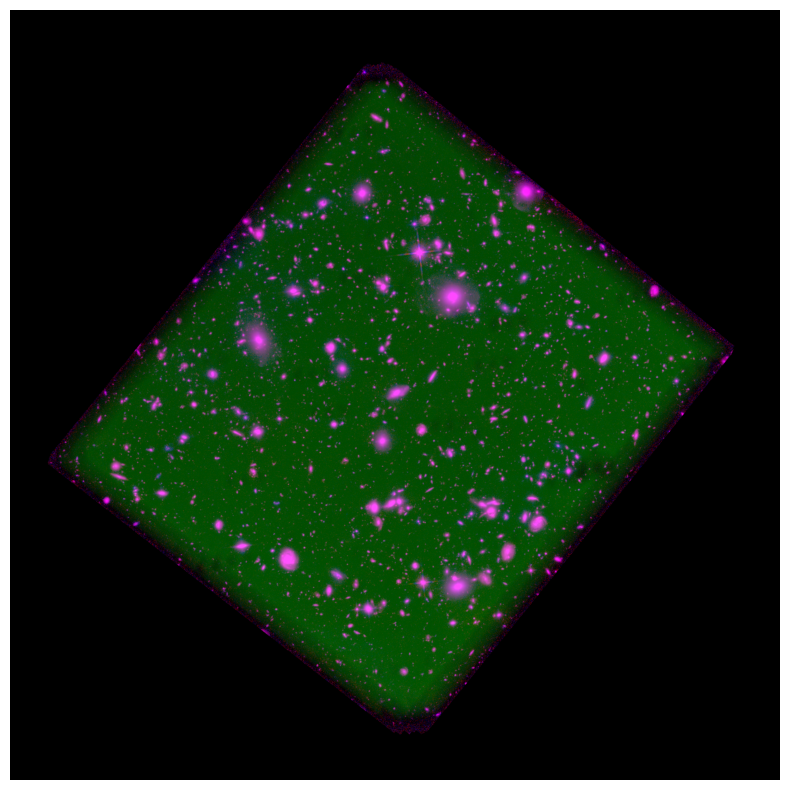

In [64]:
data1 = astrofits.open("f125w.fits")
data2 = astrofits.open("f160w.fits")

#get data
f125wData = data1[0].data
f160wData = data2[0].data

def rescaleImage(data):
    dataTemp = data.copy()
    m = np.nanmean(dataTemp)
    vplmin = m/2.
    vpmin = np.log10(vplmin)
    vpmax = np.log10(m*100.)
    dataTemp[dataTemp < vplmin] = vplmin
    dataTemp = np.log10(dataTemp)
    return dataTemp, vpmin, vpmax

#rescaled image
data1Res, d1Min, d1Max = rescaleImage(imageData)
data2Res, d2Min, d2Max = rescaleImage(f125wData)
data3Res, d3Min, d3Max = rescaleImage(f160wData)

data1Res[data1Res < d1Min] = d1Min
data1Res[data1Res > d1Max] = d1Max
data2Res[data2Res < d2Min] = d2Min
data2Res[data2Res > d2Max] = d2Max
data3Res[data3Res < d3Min] = d3Min
data3Res[data3Res > d3Max] = d3Max

#create rgb image
rgb = np.zeros((data1Res.shape[0], data1Res.shape[1], 3))
rgb[:, :, 0] = (data1Res - d1Min) / (d1Max - d1Min)
rgb[:, :, 1] = (data2Res - d2Min) / (d2Max - d2Min)
rgb[:, :, 2] = (data3Res - d3Min)  / (d3Max - d3Min)

f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.axis("off")
ax.imshow(rgb)
plt.savefig("3color.png")
